In [ ]:
import os, sys, time, math
import numpy as np
import torch
import matplotlib.pyplot as plt

# The file list shows model.py is directly in /content/
project_root = '/content'

sys.path.insert(0, project_root)
print('Project root:', project_root)

import model
from model import GPT, GPTConfig
print('Loaded successfully!')

Project root: /content
Loaded successfully!


### Device Configuration

In [ ]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
print(f"Using device: {device}")

Using device: cuda


### Data Loader setup

In [ ]:
batch_size = 32 # number of independent sequences to process in parallel
block_size = 256 # maximum context length for predictions

def get_batch(split, dataset='poems'):
    data_dir = '/content'
    filename = f"{dataset}_{split}.bin"
    filepath = os.path.join(data_dir, filename)

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Dataset file {filepath} not found.")

    data = np.memmap(filepath, dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])

    if device == 'cuda':
        x, y = x.pin_memory().to(device, non_blocking=True), y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

### Model Initialization

In [ ]:
config = GPTConfig(
    block_size=block_size,
    vocab_size=50257,
    n_layer=4,
    n_head=4,
    n_embd=128,
    dropout=0.1
)

model = GPT(config)
model.to(device)
print(f"Model parameters: {model.get_num_params()/1e6:.2f} M")

number of parameters: 7.23M
Model parameters: 7.23 M


### Training Loop & Tracker

In [ ]:
def estimate_loss(model, dataset='poems', eval_iters=50):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split, dataset)
            with torch.no_grad():
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

def get_gpu_memory():
    if device == 'cuda':
        return torch.cuda.memory_allocated() / (1024**2) # MB
    elif device == 'mps':
        return torch.mps.current_allocated_memory() / (1024**2) # MB
    return 0.0

In [ ]:
def train_model(model, dataset, max_iters=2000, eval_interval=200, learning_rate=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    # Trackers
    history = {
        'iter': [],
        'train_loss': [],
        'val_loss': [],
        'gpu_mem_mb': [],
        'time_sec': []
    }

    start_time = time.time()
    print(f"\n--- Starting {dataset.upper()} training ---")

    for iter in range(max_iters):
        # Every once in a while evaluate the loss on train and val sets
        if iter % eval_interval == 0 or iter == max_iters - 1:
            losses = estimate_loss(model, dataset)
            gpu_mem = get_gpu_memory()
            elapsed = time.time() - start_time

            history['iter'].append(iter)
            history['train_loss'].append(losses['train'])
            history['val_loss'].append(losses['val'])
            history['gpu_mem_mb'].append(gpu_mem)
            history['time_sec'].append(elapsed)

            print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f} | GPU Mem: {gpu_mem:.1f} MB | Time: {elapsed:.1f}s")

        # Sample a batch of data
        xb, yb = get_batch('train', dataset)

        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return history

### Pretraining on Poems

In [ ]:
poem_history = train_model(model, dataset='poems', max_iters=1000, eval_interval=250, learning_rate=1e-3)


--- Starting POEMS training ---
step 0: train loss 10.8454, val loss 10.8456 | GPU Mem: 37.8 MB | Time: 6.4s
step 250: train loss 5.7150, val loss 5.9432 | GPU Mem: 1699.7 MB | Time: 54.5s
step 500: train loss 5.3637, val loss 5.6569 | GPU Mem: 1699.7 MB | Time: 106.5s
step 750: train loss 5.2353, val loss 5.5062 | GPU Mem: 1699.7 MB | Time: 164.6s
step 1000: train loss 5.0706, val loss 5.3723 | GPU Mem: 1699.7 MB | Time: 222.7s
step 1250: train loss 4.8839, val loss 5.2684 | GPU Mem: 1699.7 MB | Time: 281.1s
step 1500: train loss 4.7714, val loss 5.1658 | GPU Mem: 1699.7 MB | Time: 339.2s
step 1750: train loss 4.7313, val loss 5.1476 | GPU Mem: 1699.7 MB | Time: 397.2s
step 1999: train loss 4.6548, val loss 5.0827 | GPU Mem: 1699.7 MB | Time: 455.2s


### Fine-Tuning on Raps

In [ ]:
rap_history = train_model(model, dataset='raps', max_iters=1500, eval_interval=250, learning_rate=3e-4)


--- Starting RAPS training ---
step 0: train loss 5.5994, val loss 5.7125 | GPU Mem: 73.6 MB | Time: 7.5s
step 250: train loss 4.3587, val loss 4.7317 | GPU Mem: 1699.7 MB | Time: 65.5s
step 500: train loss 4.1513, val loss 4.6224 | GPU Mem: 1699.7 MB | Time: 123.6s
step 750: train loss 4.0711, val loss 4.5931 | GPU Mem: 1699.7 MB | Time: 181.5s
step 1000: train loss 3.9250, val loss 4.5479 | GPU Mem: 1699.7 MB | Time: 239.5s
step 1250: train loss 3.8220, val loss 4.5080 | GPU Mem: 1699.7 MB | Time: 297.6s
step 1500: train loss 3.7440, val loss 4.4921 | GPU Mem: 1699.7 MB | Time: 355.7s
step 1750: train loss 3.6718, val loss 4.4706 | GPU Mem: 1699.7 MB | Time: 413.7s
step 1999: train loss 3.6111, val loss 4.4663 | GPU Mem: 1699.7 MB | Time: 472.0s


### Visualization of Training Progress

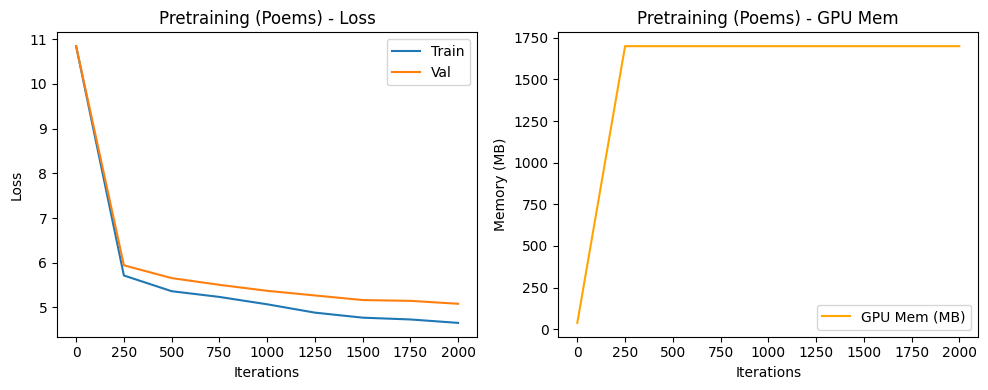

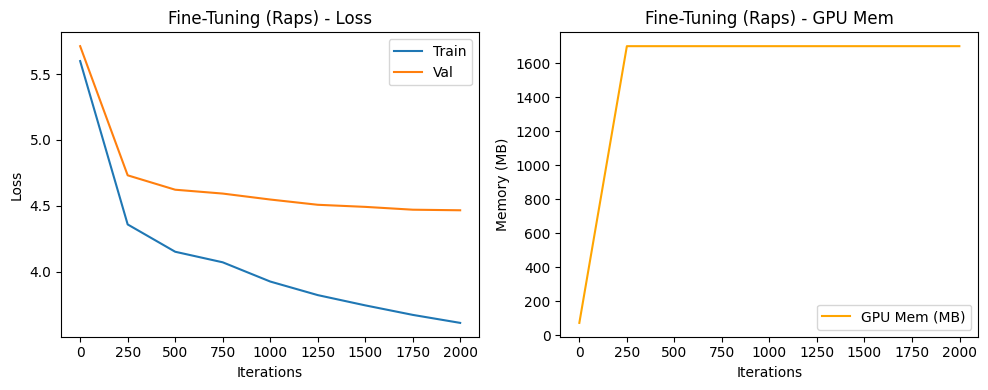

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['iter'], history['train_loss'], label='Train')
    plt.plot(history['iter'], history['val_loss'], label='Val')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['iter'], history['gpu_mem_mb'], label='GPU Mem (MB)', color='orange')
    plt.xlabel('Iterations')
    plt.ylabel('Memory (MB)')
    plt.title(f"{title} - GPU Mem")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(poem_history, "Pretraining (Poems)")
plot_history(rap_history, "Fine-Tuning (Raps)")

### Save the Model

In [ ]:
checkpoint = {
    'model': model.state_dict(),
    'config': config,
}
torch.save(checkpoint, 'nanogpt_checkpoint.pt')
print("Model saved to nanogpt_checkpoint.pt")

Model saved to nanogpt_checkpoint.pt
